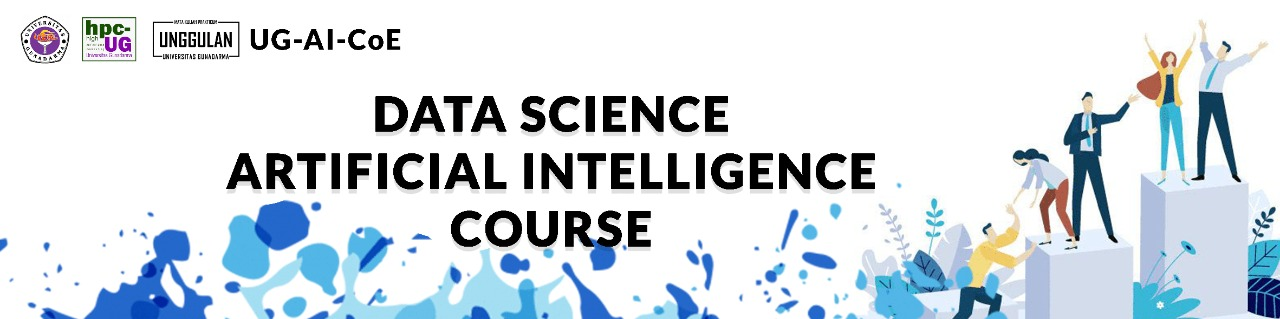

# Hands-On
---
Hands-On ini merupakan tugas tambahan customer segmentation menggunakan dataset `CC_GENERAL.csv`, disusun mengikuti alur kerja clustering yang sama seperti pada Hands-On Pertemuan 2 (Contoh Kasus).

### Tugas Tambahan - Customer Segmentation (CC_GENERAL)

### Daftar Isi:
1. Business Understanding
2. Data Understanding
3. Data Preparation
4. Modeling
    * K-Means
    * Hierarchical Clustering
    * DBSCAN
5. Evaluation

## Unsupervised Learning

Unsupervised Learning adalah salah satu pendekatan dalam *machine learning* yang digunakan untuk menganalisis data tanpa adanya label atau target yang telah ditentukan sebelumnya. Berbeda dengan supervised learning yang menggunakan data berlabel untuk mempelajari hubungan antara fitur dan target, unsupervised learning berusaha menemukan pola, struktur, hubungan, atau informasi tersembunyi yang terdapat di dalam data secara mandiri.

Secara umum, unsupervised learning dapat digunakan untuk beberapa tujuan utama, yaitu:
* Clustering: mengelompokkan data berdasarkan kemiripan karakteristik.
* Association: menemukan hubungan atau pola keterkaitan antarvariabel atau item.
* Dimensionality Reduction: mengurangi jumlah fitur atau dimensi data dengan tetap mempertahankan informasi penting.

### Clustering

Clustering adalah salah satu teknik utama dalam unsupervised learning yang bertujuan untuk membagi sekumpulan data ke dalam beberapa kelompok atau cluster berdasarkan tingkat kemiripan karakteristiknya.

Pada clustering, data tidak memiliki label kelas yang sudah ditentukan. Algoritma akan mencari struktur alami di dalam data dan menempatkan data yang memiliki karakteristik serupa ke dalam kelompok yang sama, sementara data yang memiliki karakteristik berbeda cenderung ditempatkan pada kelompok yang berbeda.

Sebagai contoh, apabila terdapat data transaksi kartu kredit yang memiliki informasi seperti saldo, jumlah pembelian, penarikan tunai, dan limit kredit, teknik clustering dapat digunakan untuk menemukan kelompok nasabah yang memiliki karakteristik transaksi serupa tanpa harus menentukan terlebih dahulu nama atau kategori kelompok tersebut.

Terdapat berbagai algoritma yang dapat digunakan untuk melakukan clustering. Beberapa algoritma yang umum digunakan antara lain:

1. **K-Means Clustering:** Mengelompokkan data ke dalam sejumlah cluster yang telah ditentukan berdasarkan kedekatan data terhadap pusat cluster (*centroid*).
2. **Hierarchical Clustering:** Membentuk struktur pengelompokan data secara bertingkat sehingga hubungan antarcluster dapat divisualisasikan dalam bentuk dendrogram.
3. **DBSCAN (Density-Based Spatial Clustering of Applications with Noise):** Mengelompokkan data berdasarkan kepadatan (*density*) dan mampu mengidentifikasi data yang dianggap sebagai noise atau pencilan.

Setiap algoritma memiliki karakteristik, kelebihan, dan keterbatasan yang berbeda. Oleh karena itu, pemilihan metode clustering perlu disesuaikan dengan karakteristik data dan tujuan analisis.

#### 1. Business Understanding

Dataset `CC_GENERAL` berisi ringkasan perilaku penggunaan kartu kredit dari sekitar 9.000 nasabah selama 6 bulan terakhir, meliputi informasi saldo (`BALANCE`), jumlah pembelian (`PURCHASES`), penarikan tunai (`CASH_ADVANCE`), limit kredit (`CREDIT_LIMIT`), pembayaran (`PAYMENTS`), dan lama keanggotaan (`TENURE`).

Permasalahan yang ingin diselesaikan adalah bagaimana mengelompokkan nasabah kartu kredit ke dalam beberapa segmen berdasarkan pola transaksi dan penggunaan kartu kredit mereka, tanpa menentukan kelompok tersebut terlebih dahulu.

Karena pendekatan yang digunakan merupakan Unsupervised Learning, tidak terdapat variabel target yang harus diprediksi. Model akan mengidentifikasi pola atau struktur yang terdapat secara alami pada data berdasarkan kemiripan perilaku transaksi nasabah.

Tujuan analisis adalah:

* Mengidentifikasi segmen nasabah kartu kredit berdasarkan pola saldo, pembelian, penarikan tunai, limit kredit, dan pembayaran.
* Membandingkan hasil clustering menggunakan algoritma K-Means, Hierarchical Clustering, dan DBSCAN.
* Menentukan algoritma clustering terbaik berdasarkan metrik evaluasi, yaitu Silhouette Score dan Davies-Bouldin Index.
* Menginterpretasikan karakteristik masing-masing segmen nasabah untuk mendukung strategi pemasaran atau manajemen risiko kartu kredit.

In [1]:
# Import library pandas untuk manipulasi data
import pandas as pd

# Membaca dataset
df = pd.read_csv('CC GENERAL.csv')

# Menampilkan 5 data pertama
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


#### 2. Data Understanding

Tahap Data Understanding bertujuan untuk memahami struktur, tipe data, jumlah data, serta karakteristik awal dari dataset.

Tahap ini penting dilakukan sebelum pemodelan karena kualitas model clustering sangat bergantung pada kualitas dan representasi data yang digunakan.

In [2]:
# Melihat ukuran dataset
df.shape

(8950, 18)

In [3]:
# Melihat informasi dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

Dataset terdiri dari 8.950 observasi dan 18 variabel. Variabel `CUST_ID` merupakan identitas nasabah, sedangkan variabel lainnya bertipe numerik (`float64` dan `int64`) yang menggambarkan perilaku transaksi kartu kredit.

In [4]:
# Melihat statistik deskriptif dari dataset
df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


In [5]:
# Cek missing value dan data duplikat
missing_value = df.isnull().sum()
print("Jumlah data missing value per kolom:")
print(missing_value[missing_value > 0])

duplicated_value = df.duplicated().sum()
print("\nJumlah data duplikat:", duplicated_value)

Jumlah data missing value per kolom:
CREDIT_LIMIT          1
MINIMUM_PAYMENTS    313
dtype: int64

Jumlah data duplikat: 0


Berdasarkan hasil pengecekan, ditemukan missing value pada variabel `CREDIT_LIMIT` (1 data) dan `MINIMUM_PAYMENTS` (313 data), sedangkan tidak ditemukan data duplikat. Selain itu, berdasarkan hasil `df.describe()`, variabel seperti `BALANCE`, `PURCHASES`, dan `CASH_ADVANCE` memiliki rentang nilai yang sangat lebar, yang mengindikasikan variasi perilaku transaksi yang besar antar nasabah.

#### Exploratory Data Analysis (EDA)

In [6]:
# Import library matplotlib dan seaborn untuk visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

Salah satu eksplorasi awal dilakukan dengan melihat hubungan antara variabel `BALANCE` dan `PURCHASES` menggunakan scatterplot.

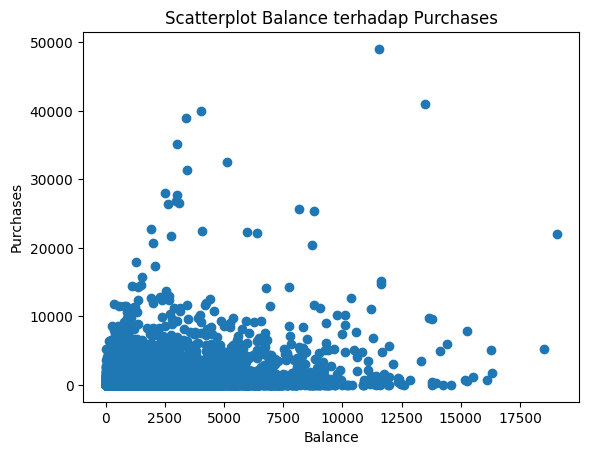

In [7]:
plt.scatter(
    df["BALANCE"],
    df["PURCHASES"]
    )

plt.xlabel("Balance")
plt.ylabel("Purchases")
plt.title("Scatterplot Balance terhadap Purchases")
plt.show()

Berdasarkan scatterplot tersebut, persebaran data belum menunjukkan kelompok yang terbentuk secara jelas. Visualisasi ini memberikan gambaran awal mengenai hubungan antara saldo (`BALANCE`) dan total pembelian (`PURCHASES`). Meskipun terdapat pola persebaran tertentu, batas antar kelompok belum terlihat secara jelas. Oleh karena itu, diperlukan proses clustering untuk mengidentifikasi kelompok nasabah berdasarkan kemiripan perilaku transaksi kartu kredit.

#### 3. Data Preparation

##### Data Cleaning dan Pengambilan 1.000 Data Bersih

Baris yang memiliki missing value dihapus terlebih dahulu, kemudian diambil **1.000 data bersih** secara acak (random sampling) dengan `random_state` tetap agar hasil dapat direproduksi.

In [8]:
# Menghapus baris yang memiliki missing value
df_clean = df.dropna().reset_index(drop=True)

print("Jumlah data sebelum cleaning:", df.shape[0])
print("Jumlah data setelah cleaning (tanpa missing value):", df_clean.shape[0])

# Mengambil 1.000 data bersih secara acak
df = df_clean.sample(n=1000, random_state=42).reset_index(drop=True)

print("Jumlah data yang digunakan:", df.shape[0])

Jumlah data sebelum cleaning: 8950
Jumlah data setelah cleaning (tanpa missing value): 8636
Jumlah data yang digunakan: 1000


Proses clustering menggunakan enam variabel numerik yang merepresentasikan perilaku transaksi nasabah, yaitu `BALANCE`, `PURCHASES`, `CASH_ADVANCE`, `CREDIT_LIMIT`, `PAYMENTS`, dan `TENURE`.

In [9]:
# Fitur yang digunakan
features = [
    "BALANCE",
    "PURCHASES",
    "CASH_ADVANCE",
    "CREDIT_LIMIT",
    "PAYMENTS",
    "TENURE"
]

X = df[features]

X.head()

,BALANCE,PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,TENURE
0,154.439292,1047.94,0.000000,6000.0,1032.089965,12
1,467.220993,1110.17,814.088229,4000.0,2514.118359,12
2,435.553960,1522.06,0.000000,3000.0,1878.606679,12
3,61.628782,457.31,0.000000,1500.0,364.254422,8
4,6787.661776,99.50,7726.511679,8000.0,1775.139580,12


Selanjutnya, dilakukan standardisasi terhadap seluruh fitur agar memiliki skala yang sebanding. Hal ini penting karena perbedaan skala (misalnya `BALANCE` dan `CREDIT_LIMIT` yang bernilai ribuan, dibanding `TENURE` yang bernilai satuan) dapat memengaruhi perhitungan jarak pada proses clustering.

In [10]:
# Import library Standard Scaler
from sklearn.preprocessing import StandardScaler

In [11]:
# Pre-processing data

scaler = StandardScaler()
scaled_data = scaler.fit_transform(X)
scaled_data = pd.DataFrame(scaled_data, columns=features)

scaled_data.head()

,BALANCE,PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,TENURE
0,-0.692312,0.006025,-0.499620,0.397379,-0.277890,0.363143
1,-0.546362,0.035176,-0.050783,-0.146138,0.366801,0.363143
2,-0.561138,0.228126,-0.499620,-0.417896,0.090350,0.363143
3,-0.735619,-0.270655,-0.499620,-0.825534,-0.568403,-2.613442
4,2.402876,-0.438270,3.760291,0.940895,0.045341,0.363143


#### 4. Modeling

Setelah tahap preprocessing, data yang telah melalui proses standardisasi digunakan untuk melakukan clustering menggunakan tiga algoritma, yaitu K-Means, Hierarchical Clustering, dan DBSCAN.

##### **4.1. K-Means Clustering**

Untuk K-Means, jumlah cluster perlu ditentukan terlebih dahulu. Elbow Method dapat digunakan untuk melihat titik perubahan penurunan inertia.

Dalam K-Means, inertia mengukur seberapa jauh data dalam suatu cluster dari pusat clusternya (centroid). Semakin kecil inertia, berarti data dalam cluster semakin dekat dengan centroid.

In [12]:
# Tentukan jumlah cluster menggunakan Elbow Method
from sklearn.cluster import KMeans

inertia = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10)

    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

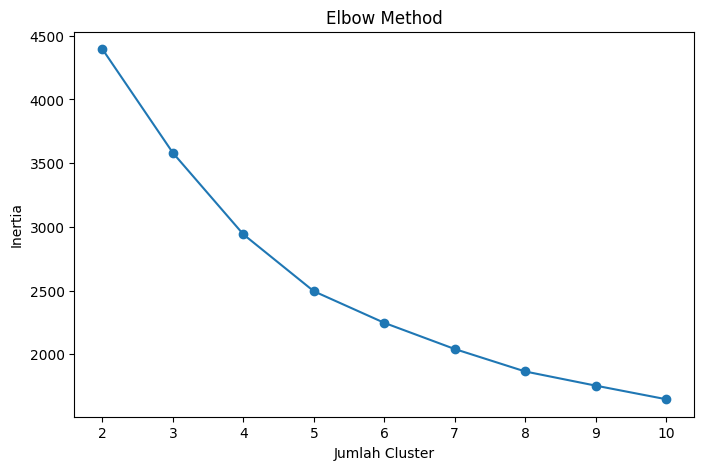

In [13]:
# Visualisasikan Elbow Method
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    inertia,
    marker="o"
)

plt.xlabel("Jumlah Cluster")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

Berdasarkan grafik di atas, penurunan inertia mulai melandai setelah K = 2, yang mengindikasikan bahwa penambahan cluster di atas titik tersebut tidak lagi memberikan pengurangan inertia yang signifikan.

Untuk memperkuat penentuan jumlah cluster, dihitung pula Silhouette Score untuk beberapa jumlah cluster.

In [14]:
# Hitung Silhouette Score untuk beberapa jumlah cluster
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10)

    labels = kmeans.fit_predict(scaled_data)

    score = silhouette_score(
        scaled_data,
        labels)

    silhouette_scores.append(score)

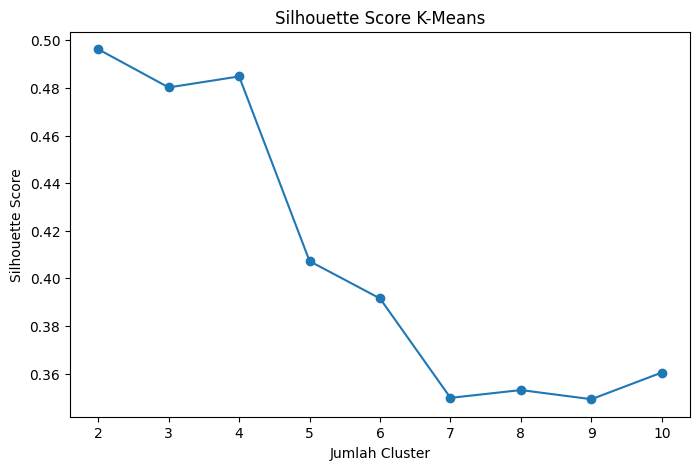

In [15]:
# Visualisasikan Silhouette Score
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    silhouette_scores,
    marker="o"
)

plt.xlabel("Jumlah Cluster")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score K-Means")

plt.show()

Berdasarkan hasil pengujian pada beberapa jumlah cluster, Silhouette Score tertinggi diperoleh pada K = 2. Hasil ini sejalan dengan Elbow Method, sehingga K-Means digunakan dengan jumlah K = 2 pada tahap clustering berikutnya.

Setelah mendapatkan jumlah cluster terbaik:

In [16]:
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(scaled_data)

df["KMeans_Cluster"] = kmeans_labels
df["KMeans_Cluster"].value_counts().sort_index()

KMeans_Cluster
0    826
1    174
Name: count, dtype: int64

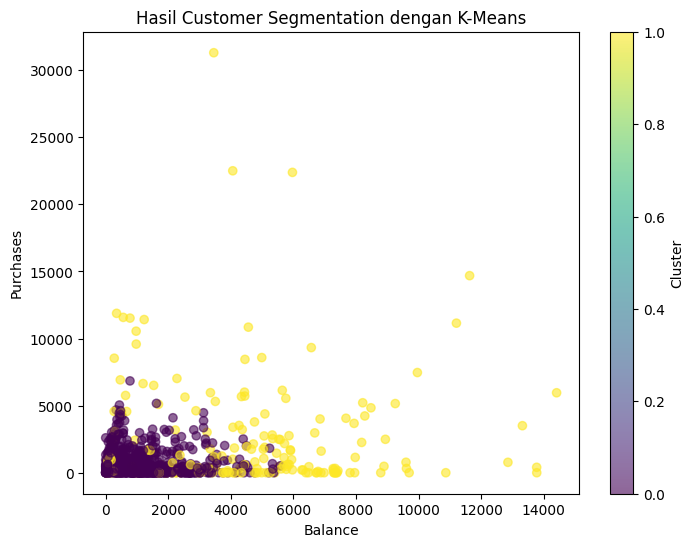

In [17]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df["BALANCE"],
    df["PURCHASES"],
    c=df["KMeans_Cluster"],
    cmap="viridis",
    alpha=0.6
)

plt.xlabel("Balance")
plt.ylabel("Purchases")
plt.title("Hasil Customer Segmentation dengan K-Means")

plt.colorbar(
    label="Cluster"
)

plt.show()

K-Means mengelompokkan nasabah ke dalam 2 cluster berdasarkan kedekatan data terhadap centroid masing-masing cluster.

##### **4.2. Hierarchical Clustering**

Pada Hierarchical Clustering, penentuan jumlah cluster dilakukan dengan menggunakan dendrogram. Dendrogram digunakan untuk melihat proses penggabungan data berdasarkan tingkat kemiripannya.

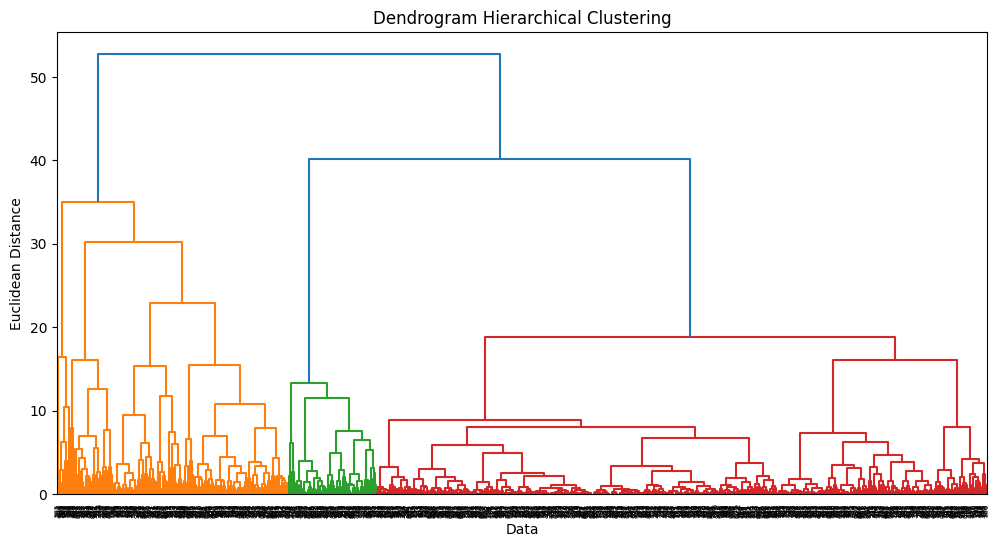

In [18]:
from scipy.cluster.hierarchy import dendrogram, linkage

# Membuat linkage matrix
Z = linkage(scaled_data, method="ward")

# Plot dendrogram
plt.figure(figsize=(12, 6))
dendrogram(Z)

plt.title("Dendrogram Hierarchical Clustering")
plt.xlabel("Data")
plt.ylabel("Euclidean Distance")
plt.show()

Berdasarkan hasil dendrogram, pemotongan pada jarak tertentu menghasilkan 2 cluster. Oleh karena itu, jumlah cluster yang digunakan pada Hierarchical Clustering ditetapkan sebanyak 2 cluster, sehingga dapat dibandingkan secara konsisten dengan hasil K-Means yang juga menggunakan 2 cluster.

In [19]:
from sklearn.cluster import AgglomerativeClustering

hierarchical = AgglomerativeClustering(
    n_clusters=2,
    linkage="ward"
    )

hierarchical_labels = hierarchical.fit_predict(
    scaled_data
    )

df["Hierarchical_Cluster"] = hierarchical_labels
df["Hierarchical_Cluster"].value_counts().sort_index()

Hierarchical_Cluster
0    751
1    249
Name: count, dtype: int64

##### **4.3. DBSCAN**

Berbeda dengan K-Means dan Hierarchical Clustering, DBSCAN tidak membutuhkan jumlah cluster di awal. DBSCAN memiliki dua parameter utama:
* `eps` → radius/jarak maksimum antar data dalam suatu neighborhood.
* `min_samples` → jumlah minimum data untuk membentuk area yang dianggap padat.

Untuk menentukan parameter terbaik, dicoba beberapa kombinasi:

In [20]:
from sklearn.cluster import DBSCAN

dbscan_results = []

for eps in [0.5, 0.7, 1.0, 1.5, 2.0]:
    for min_samples in [5, 10, 15]:

        model = DBSCAN(
            eps=eps,
            min_samples=min_samples
        )

        labels = model.fit_predict(scaled_data)

        # Mengabaikan noise (-1)
        mask = labels != -1

        n_clusters = len(
            set(labels[mask])
        )

        if n_clusters >= 2:
            score = silhouette_score(
                scaled_data[mask],
                labels[mask]
            )
        else:
            score = -1

        dbscan_results.append({
            "eps": eps,
            "min_samples": min_samples,
            "clusters": n_clusters,
            "noise": (labels == -1).sum(),
            "silhouette": score
        })

dbscan_results = pd.DataFrame(
    dbscan_results
)

dbscan_results.sort_values(
    "silhouette",
    ascending=False
).head(10)

,eps,min_samples,clusters,noise,silhouette
9,1.5,5,2,49,0.644989
1,0.5,10,3,438,0.124811
5,0.7,15,5,341,0.077726
4,0.7,10,4,314,0.068754
0,0.5,5,9,363,0.047737
3,0.7,5,7,238,0.026672
2,0.5,15,1,490,-1.000000
6,1.0,5,1,125,-1.000000
7,1.0,10,1,143,-1.000000
8,1.0,15,1,162,-1.000000


Pada tahap ini dilakukan percobaan beberapa kombinasi eps dan min_samples untuk menemukan parameter yang sesuai dengan karakteristik dataset. Jumlah cluster dan jumlah data yang dianggap sebagai noise juga dicatat untuk setiap kombinasi.

Ambil parameter terbaik:

In [21]:
dbscan = DBSCAN(
    eps=1.5,
    min_samples=5)

dbscan_labels = dbscan.fit_predict(
    scaled_data)

df["DBSCAN_Cluster"] = dbscan_labels
df["DBSCAN_Cluster"].value_counts().sort_index()

DBSCAN_Cluster
-1     49
 0    945
 1      6
Name: count, dtype: int64

#### 5. Evaluation

Setelah ketiga algoritma menghasilkan cluster, kita bandingkan menggunakan Silhouette Score dan Davies-Bouldin Index.

In [22]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

# K-Means Clustering
sil_kmeans = silhouette_score(scaled_data, kmeans_labels)
db_kmeans = davies_bouldin_score(scaled_data, kmeans_labels)

# Hierarchical Clustering
sil_hierarchical = silhouette_score(scaled_data, hierarchical_labels)
db_hierarchical = davies_bouldin_score(scaled_data, hierarchical_labels)

# DBSCAN
mask = dbscan_labels != -1

if len(set(dbscan_labels[mask])) >= 2:
    sil_dbscan = silhouette_score(
        scaled_data[mask],
        dbscan_labels[mask])

    db_dbscan = davies_bouldin_score(
       scaled_data[mask],
        dbscan_labels[mask])
else:
    sil_dbscan = None
    db_dbscan = None

In [23]:
# Tabel Perbandingan Hasil Evaluasi
evaluation = pd.DataFrame({
    "Algorithm": [
        "K-Means",
        "Hierarchical",
        "DBSCAN"
    ],
    "Silhouette Score": [
        sil_kmeans,
        sil_hierarchical,
        sil_dbscan
    ],
    "Davies-Bouldin Index": [
        db_kmeans,
        db_hierarchical,
        db_dbscan
    ]
})

evaluation

,Algorithm,Silhouette Score,Davies-Bouldin Index
0,K-Means,0.496278,1.361604
1,Hierarchical,0.400211,1.519534
2,DBSCAN,0.644989,0.397725


Berdasarkan hasil evaluasi, secara angka DBSCAN menghasilkan Silhouette Score tertinggi (sekitar 0.645) dan Davies-Bouldin Index terendah (sekitar 0.398) dibandingkan K-Means (Silhouette Score sekitar 0.496; Davies-Bouldin Index sekitar 1.362) dan Hierarchical Clustering (Silhouette Score sekitar 0.400; Davies-Bouldin Index sekitar 1.520).

Meskipun demikian, hasil DBSCAN perlu dicermati lebih lanjut karena distribusi clusternya sangat tidak seimbang (satu cluster besar berisi hampir seluruh data, satu cluster sangat kecil, dan sekitar 49 data dianggap sebagai noise/outlier). Kondisi ini membuat DBSCAN unggul secara metrik, namun secara bisnis kurang informatif untuk segmentasi nasabah dibandingkan K-Means, yang menghasilkan dua cluster dengan proporsi lebih seimbang dan lebih mudah diinterpretasikan.

Oleh karena itu, untuk kebutuhan interpretasi segmentasi nasabah pada kasus ini, hasil **K-Means** dipilih sebagai model utama, sedangkan DBSCAN lebih berguna untuk mengidentifikasi nasabah dengan pola transaksi ekstrem (outlier).

In [24]:
cluster_profile = df.groupby(
    "KMeans_Cluster"
)[features].mean().round(2)

cluster_profile

,BALANCE,PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,TENURE
KMeans_Cluster,,,,,,
0,984.43,678.44,484.11,3413.50,1070.27,11.46
1,4741.23,2728.10,2909.91,9874.71,4522.22,11.75


Berdasarkan hasil `cluster_profile`, diperoleh interpretasi sebagai berikut:

* **Cluster 0** merupakan kelompok nasabah dengan `BALANCE`, `PURCHASES`, `CASH_ADVANCE`, `CREDIT_LIMIT`, dan `PAYMENTS` yang relatif lebih rendah. Kelompok ini dapat dikategorikan sebagai nasabah dengan aktivitas transaksi kartu kredit yang ringan hingga menengah.
* **Cluster 1** merupakan kelompok nasabah dengan seluruh variabel keuangan yang jauh lebih tinggi, termasuk saldo, total pembelian, penarikan tunai, limit kredit, dan pembayaran. Kelompok ini dapat dikategorikan sebagai nasabah dengan aktivitas transaksi tinggi (heavy users) dan kemungkinan memiliki profil kredit yang lebih besar.

Kedua cluster memiliki `TENURE` (lama keanggotaan) yang relatif mirip, sehingga variabel yang paling membedakan kedua segmen bukan pada lamanya menjadi nasabah, melainkan pada besarnya nilai transaksi dan limit kredit yang dimiliki.

**Kesimpulan:**

1. Secara angka, DBSCAN paling unggul (Silhouette Score tertinggi, Davies-Bouldin Index terendah), tetapi hasil ini didapat dengan membuang sekitar 49 data sebagai noise dan menghasilkan cluster yang sangat timpang (945 vs 6 data), sehingga kurang berguna untuk interpretasi bisnis.
2. **K-Means dengan K = 2 dipilih sebagai model utama** karena menghasilkan dua kelompok nasabah yang seimbang dan mudah dijelaskan.
3. Segmentasi ini dapat dimanfaatkan, misalnya, untuk menargetkan program loyalitas atau penawaran kenaikan limit kredit pada Cluster 1 (heavy users), serta strategi edukasi atau promosi penggunaan kartu kredit pada Cluster 0 agar aktivitas transaksinya meningkat.
4. DBSCAN tetap berguna sebagai alat tambahan untuk mendeteksi nasabah dengan pola transaksi ekstrem/anomali yang perlu perhatian khusus (misalnya untuk manajemen risiko).

---

Tugas Tambahan Customer Segmentation - CC_GENERAL Dataset